## INSTALLED ENERGY CAPACITY IN INDIA BY STATE

This dataset directs to the installed energy capacity in every state of India.This data includes details such as region,state,sector,energy sources(coal,gas,diesel,lignite,hydro and renewable energy).This data offers a valuable resource to gather,analyze and interpret data related to energy and electricity generation in India.

In [1]:
# Importing required python libraries for analysis and visualization

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Loading the dataset for analysis,the data is in csv format.

In [2]:
cp = pd.read_csv('installed-capacity-statewise.csv')

Now we have to check the loaded data by viewing the data with few values using head function.

In [3]:
cp.head()

,id,date,region,state_name,state_code,sector,coal_cap,gas_cap,diesel_cap,lignite_cap,nuclear_cap,hydro_cap,res_cap
0,0,2017-11-01,Eastern,Andaman And Nicobar Islands,35,Central,0.0,0.0,0.00,0.0,0.00,0.0,0.0
1,1,2017-11-01,Eastern,Andaman And Nicobar Islands,35,Private,0.0,0.0,0.00,0.0,6.10,0.0,0.0
2,2,2017-11-01,Eastern,Andaman And Nicobar Islands,35,State,0.0,0.0,40.05,0.0,5.25,0.0,0.0
3,3,2017-11-01,Eastern,Bihar,10,Central,4770.0,0.0,0.00,0.0,0.00,0.0,0.0
4,4,2017-11-01,Eastern,Bihar,10,Private,0.0,0.0,0.00,0.0,253.58,0.0,0.0


Next, going to check how many values present in the dataset.

In [4]:
cp.shape


(9336, 13)

There are 9336 rows and 13 columns present in the data.

Next, i will explain the columns in the dataset.

In [5]:
cp.columns

Index(['id', 'date', 'region', 'state_name', 'state_code', 'sector',
       'coal_cap', 'gas_cap', 'diesel_cap', 'lignite_cap', 'nuclear_cap',
       'hydro_cap', 'res_cap'],
      dtype='object')

Here there are 13 columns, understanding the columns is very essential before analysis.

id - id column

Date - Date of recorded installed capacity data

Region - Geographical region of the state(North,South,East,West,etc.)

State_name - Name of the Indian state or union territory

State_code - Codes of the state

Sector - Ownership sector of the power plant (Central,Private,State)

coal_cap - Installed electricity generation capacity from coal power plants (MW)

lignite_cap	- Installed capacity from lignite-based power plants (MW)

gas_cap - Installed capacity from natural gas power plants (MW)

diesel_cap - Installed capacity from diesel-based power plants (MW)

nuclear_cap	- Installed electricity generation capacity from nuclear power plants (MW)

hydro_cap - Installed hydroelectric power generation capacity (MW)

res_cap - Installed renewable energy capacity such as solar and wind (MW)

Next is going  to check the data types and is there any null values in the data.

In [6]:
cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9336 entries, 0 to 9335
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           9336 non-null   int64  
 1   date         9336 non-null   object 
 2   region       9336 non-null   object 
 3   state_name   9336 non-null   object 
 4   state_code   9336 non-null   int64  
 5   sector       9336 non-null   object 
 6   coal_cap     9336 non-null   float64
 7   gas_cap      9336 non-null   float64
 8   diesel_cap   9336 non-null   float64
 9   lignite_cap  9336 non-null   float64
 10  nuclear_cap  9336 non-null   float64
 11  hydro_cap    9336 non-null   float64
 12  res_cap      9336 non-null   float64
dtypes: float64(7), int64(2), object(4)
memory usage: 948.3+ KB


In the above observation the 'date' column datatype is object, so we have to change the datatype.And there is no null value in the data.

In [7]:
cp['date'] = pd.to_datetime(cp['date'])

Rechecking the datatypes.

In [8]:
cp.dtypes

id                      int64
date           datetime64[ns]
region                 object
state_name             object
state_code              int64
sector                 object
coal_cap              float64
gas_cap               float64
diesel_cap            float64
lignite_cap           float64
nuclear_cap           float64
hydro_cap             float64
res_cap               float64
dtype: object

Rearranging the columns and capitalising the tiltles of the columns.

In [9]:
new_order = ['id','date','state_code','state_name','region','sector','coal_cap',
            'gas_cap','diesel_cap','lignite_cap','nuclear_cap','hydro_cap','res_cap']

cp = cp[[col for col in new_order if col in cp.columns]]

In [10]:
cp.columns = cp.columns.str.replace('_', ' ').str.title()

Viewing the dataset again to check datas are changed to the given order.

In [11]:
cp.head()

,Id,Date,State Code,State Name,Region,Sector,Coal Cap,Gas Cap,Diesel Cap,Lignite Cap,Nuclear Cap,Hydro Cap,Res Cap
0,0,2017-11-01,35,Andaman And Nicobar Islands,Eastern,Central,0.0,0.0,0.00,0.0,0.00,0.0,0.0
1,1,2017-11-01,35,Andaman And Nicobar Islands,Eastern,Private,0.0,0.0,0.00,0.0,6.10,0.0,0.0
2,2,2017-11-01,35,Andaman And Nicobar Islands,Eastern,State,0.0,0.0,40.05,0.0,5.25,0.0,0.0
3,3,2017-11-01,10,Bihar,Eastern,Central,4770.0,0.0,0.00,0.0,0.00,0.0,0.0
4,4,2017-11-01,10,Bihar,Eastern,Private,0.0,0.0,0.00,0.0,253.58,0.0,0.0


Next, is to check any duplicate values present in the dataset.

In [12]:
cp.duplicated().sum()

0

Next, satatistical summary of the numerical datas in the dataset such as count,mean,standard deviation etc.

In [13]:
cp[['Coal Cap','Gas Cap','Diesel Cap','Lignite Cap','Nuclear Cap','Hydro Cap','Res Cap']].describe()

,Coal Cap,Gas Cap,Diesel Cap,Lignite Cap,Nuclear Cap,Hydro Cap,Res Cap
count,9336.000000,9336.000000,9336.000000,9336.000000,9336.000000,9336.000000,9336.000000
mean,1951.390601,237.550119,5.683488,28.363325,465.628693,236.407700,808.573473
std,3061.549395,708.434028,30.132927,242.449867,1927.699471,730.486406,2962.244397
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.800000
75%,3200.000000,32.500000,0.000000,0.000000,49.100000,0.000000,256.610000
max,13168.000000,4663.140000,411.700000,3390.000000,15569.410000,7884.020000,33357.490000


creating new columns from existing data to gain better insights and analysis.

creating column for total electricity generation capacity of each state in sector wise.

In [14]:
cp['Total Cap'] = (
    cp['Coal Cap'] + cp['Lignite Cap'] + cp['Gas Cap'] + cp['Diesel Cap'] +
    cp['Nuclear Cap'] + cp['Hydro Cap'] + cp['Res Cap']
)
cp.head()

,Id,Date,State Code,State Name,Region,Sector,Coal Cap,Gas Cap,Diesel Cap,Lignite Cap,Nuclear Cap,Hydro Cap,Res Cap,Total Cap
0,0,2017-11-01,35,Andaman And Nicobar Islands,Eastern,Central,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.00
1,1,2017-11-01,35,Andaman And Nicobar Islands,Eastern,Private,0.0,0.0,0.00,0.0,6.10,0.0,0.0,6.10
2,2,2017-11-01,35,Andaman And Nicobar Islands,Eastern,State,0.0,0.0,40.05,0.0,5.25,0.0,0.0,45.30
3,3,2017-11-01,10,Bihar,Eastern,Central,4770.0,0.0,0.00,0.0,0.00,0.0,0.0,4770.00
4,4,2017-11-01,10,Bihar,Eastern,Private,0.0,0.0,0.00,0.0,253.58,0.0,0.0,253.58


Creating column for fossil fuel capacity of each state in sector wise.

In [15]:
cp['Fossil Fuel Cap'] = (
    cp['Coal Cap'] + cp['Lignite Cap'] + cp['Gas Cap'] + cp['Diesel Cap']
)
cp.head()

,Id,Date,State Code,State Name,Region,Sector,Coal Cap,Gas Cap,Diesel Cap,Lignite Cap,Nuclear Cap,Hydro Cap,Res Cap,Total Cap,Fossil Fuel Cap
0,0,2017-11-01,35,Andaman And Nicobar Islands,Eastern,Central,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.00,0.00
1,1,2017-11-01,35,Andaman And Nicobar Islands,Eastern,Private,0.0,0.0,0.00,0.0,6.10,0.0,0.0,6.10,0.00
2,2,2017-11-01,35,Andaman And Nicobar Islands,Eastern,State,0.0,0.0,40.05,0.0,5.25,0.0,0.0,45.30,40.05
3,3,2017-11-01,10,Bihar,Eastern,Central,4770.0,0.0,0.00,0.0,0.00,0.0,0.0,4770.00,4770.00
4,4,2017-11-01,10,Bihar,Eastern,Private,0.0,0.0,0.00,0.0,253.58,0.0,0.0,253.58,0.00


Creating column for clean energy capacity,which are generated from nuclear,hydro and renewable energy of each state in sector wise.

In [16]:
cp['Clean Energy Cap'] = (
    cp['Nuclear Cap'] + cp['Hydro Cap'] + cp['Res Cap']
)
cp.head()

,Id,Date,State Code,State Name,Region,Sector,Coal Cap,Gas Cap,Diesel Cap,Lignite Cap,Nuclear Cap,Hydro Cap,Res Cap,Total Cap,Fossil Fuel Cap,Clean Energy Cap
0,0,2017-11-01,35,Andaman And Nicobar Islands,Eastern,Central,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.00
1,1,2017-11-01,35,Andaman And Nicobar Islands,Eastern,Private,0.0,0.0,0.00,0.0,6.10,0.0,0.0,6.10,0.00,6.10
2,2,2017-11-01,35,Andaman And Nicobar Islands,Eastern,State,0.0,0.0,40.05,0.0,5.25,0.0,0.0,45.30,40.05,5.25
3,3,2017-11-01,10,Bihar,Eastern,Central,4770.0,0.0,0.00,0.0,0.00,0.0,0.0,4770.00,4770.00,0.00
4,4,2017-11-01,10,Bihar,Eastern,Private,0.0,0.0,0.00,0.0,253.58,0.0,0.0,253.58,0.00,253.58


 ### Visualization

The pie chart shows the India’s dependence on coal vs renewable source of energy.

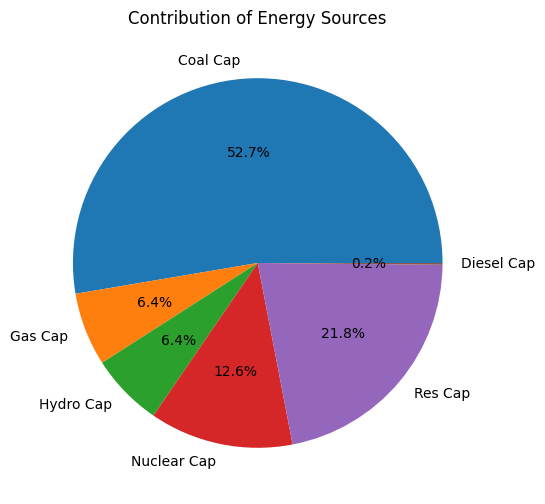

In [17]:
plt.figure(figsize=(6,6))
energy_totals = cp[
    ['Coal Cap','Gas Cap','Hydro Cap',
     'Nuclear Cap','Res Cap','Diesel Cap']
].sum()
plt.pie(energy_totals.values,
        labels=energy_totals.index,
        autopct='%1.1f%%')
plt.title('Contribution of Energy Sources')
plt.show()

The bar chart shows the state-wise total energy capacity in India.

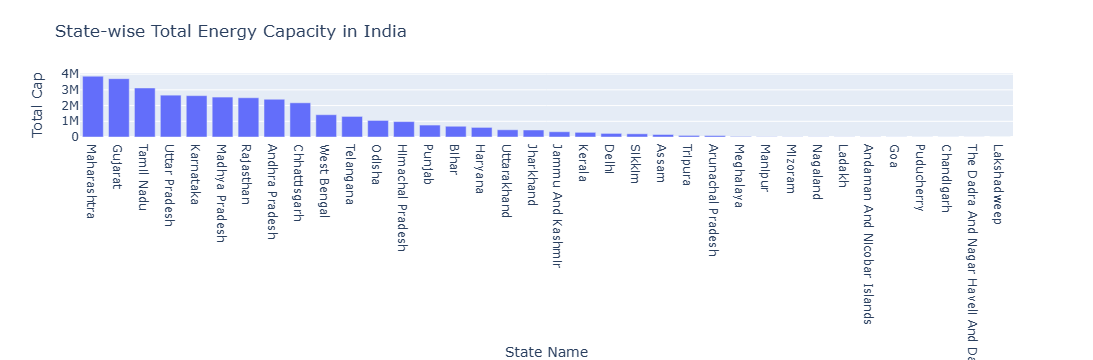

In [18]:
top_states = cp.groupby('State Name')['Total Cap'].sum().reset_index()

fig = px.bar(
    top_states.sort_values(by='Total Cap', ascending=False),
    x='State Name',
    y='Total Cap',
    title='State-wise Total Energy Capacity in India',
)

fig.show()

The pie chart shows sector wise energy distribution

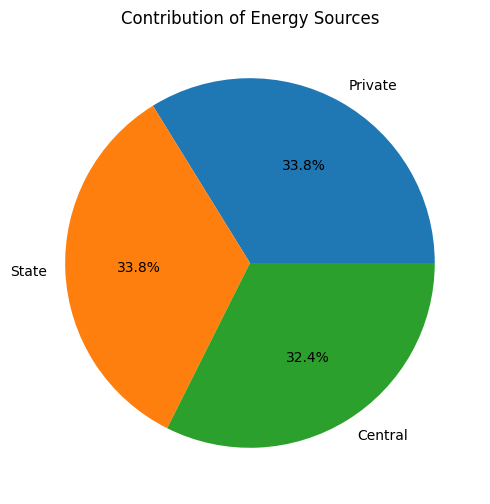

In [19]:
plt.figure(figsize=(6,6))
sector_wise = cp[
    'Sector'
    ].value_counts()
plt.pie(sector_wise.values,
        labels=sector_wise.index,
        autopct='%1.1f%%')
plt.title('Contribution of Energy Sources')
plt.show()

The heatmap shows the correlation between various energy capacities.

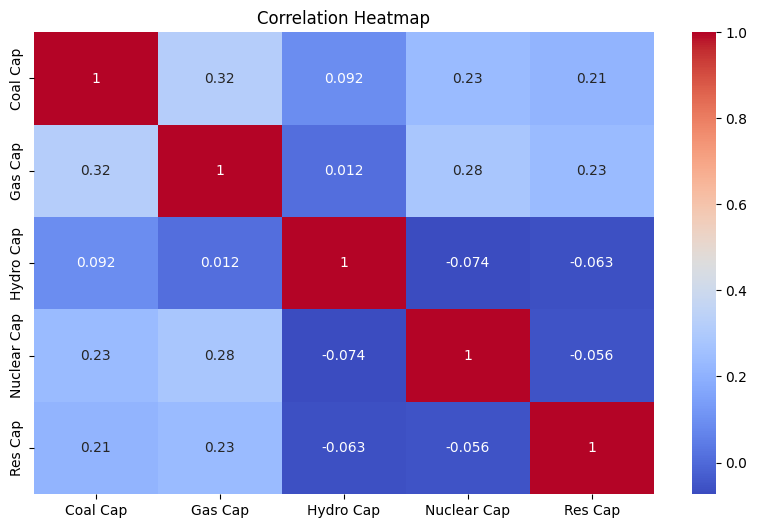

In [20]:
plt.figure(figsize=(10,6))
selected_data = cp[
    ['Coal Cap', 'Gas Cap', 'Hydro Cap',
     'Nuclear Cap', 'Res Cap']
]
sns.heatmap(
    selected_data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

The bar chart shows the top states in India with renewable source of energy capacity.

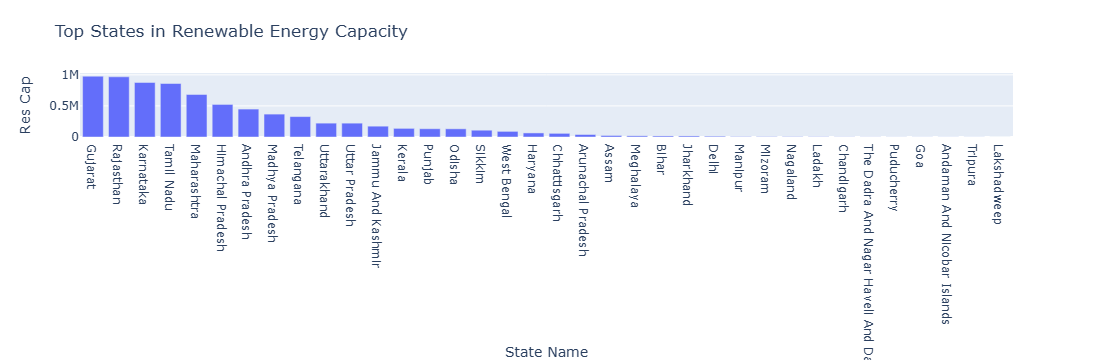

In [21]:
renew = cp.groupby('State Name')['Res Cap'].sum().reset_index()

fig = px.bar(
    renew.sort_values(by='Res Cap', ascending=False),
    x='State Name',
    y='Res Cap',
    title='Top States in Renewable Energy Capacity'
)

fig.show()

The scatter plot shows the coal vs renewable source of energy capacity through sector wise.

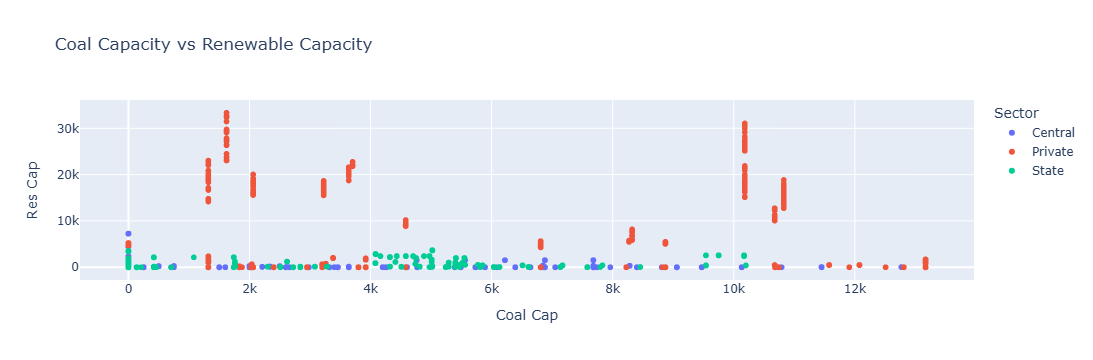

In [22]:
fig = px.scatter(
    cp,
    x='Coal Cap',
    y='Res Cap',
    color='Sector',
    hover_name='State Name',
    title='Coal Capacity vs Renewable Capacity'
)

fig.show()

The stacked bar chart shows the various energy sources in the top 10 states. 

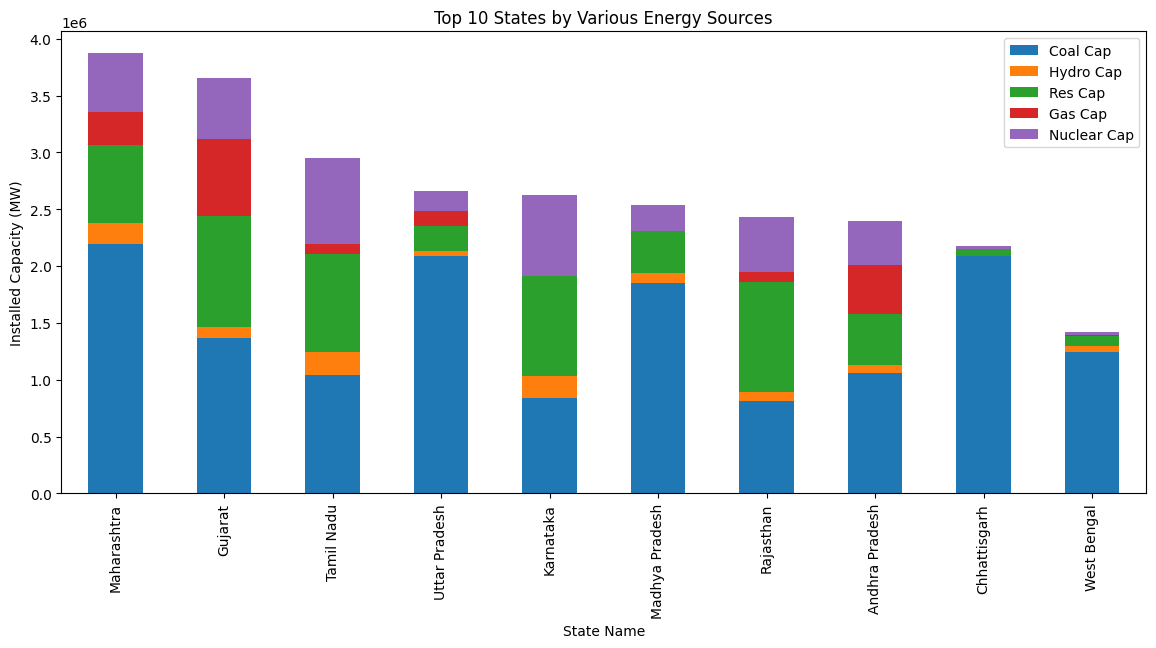

In [23]:
top_states = cp.groupby('State Name')[
    ['Coal Cap', 'Hydro Cap', 'Res Cap',
     'Gas Cap', 'Nuclear Cap']
].sum()

top_states['Total'] = top_states.sum(axis=1)

top10 = top_states.sort_values(
    by='Total',
    ascending=False
).head(10)

top10.drop(columns='Total').plot(
    kind='bar',
    stacked=True,
    figsize=(14,6)
)

plt.title('Top 10 States by Various Energy Sources')
plt.ylabel('Installed Capacity (MW)')
plt.show()

The scatter plot shows fossil fuel vs clean energy comparison in Indian states.

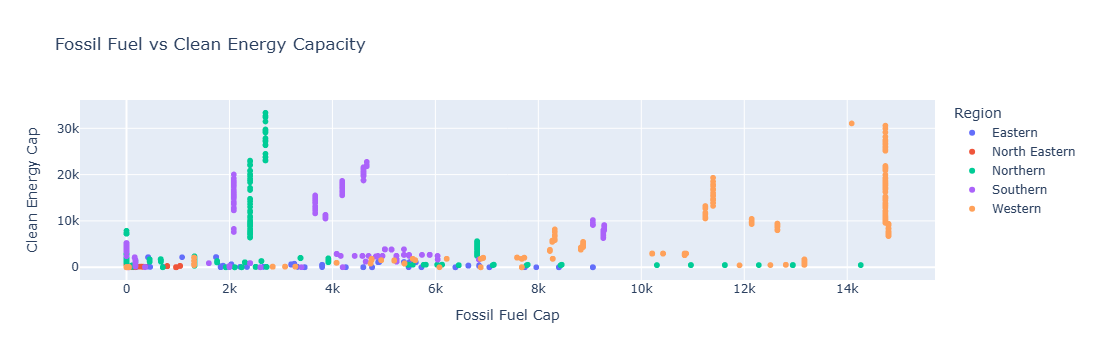

In [24]:
fig = px.scatter(
    cp,
    x='Fossil Fuel Cap',
    y='Clean Energy Cap',
    color='Region',
    hover_name='State Name',
    title='Fossil Fuel vs Clean Energy Capacity'
)

fig.show()

The boxplot shows the clean energy distribution in India.

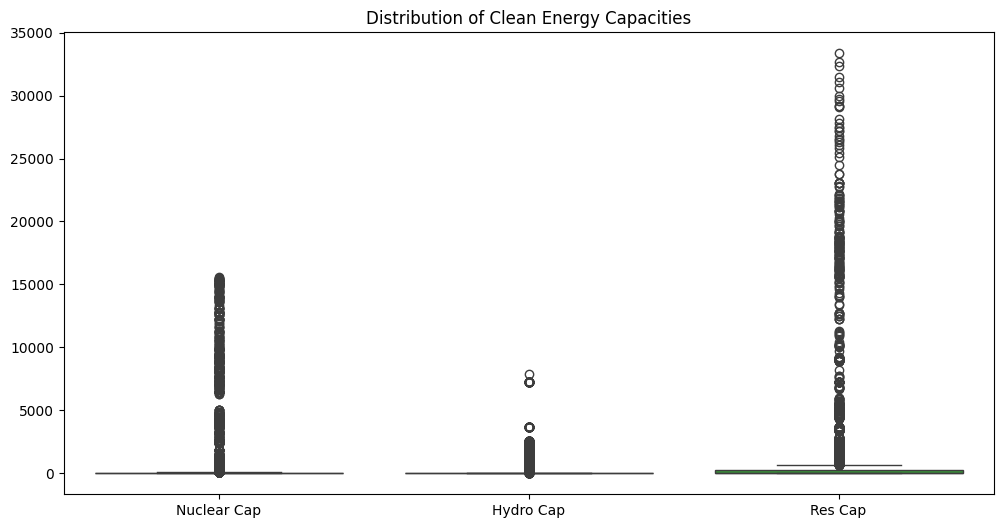

In [25]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=cp[
        ['Nuclear Cap', 
         'Hydro Cap', 'Res Cap']
    ]
)

plt.title('Distribution of Clean Energy Capacities')

plt.show()

The line plot shows state wise total capacity

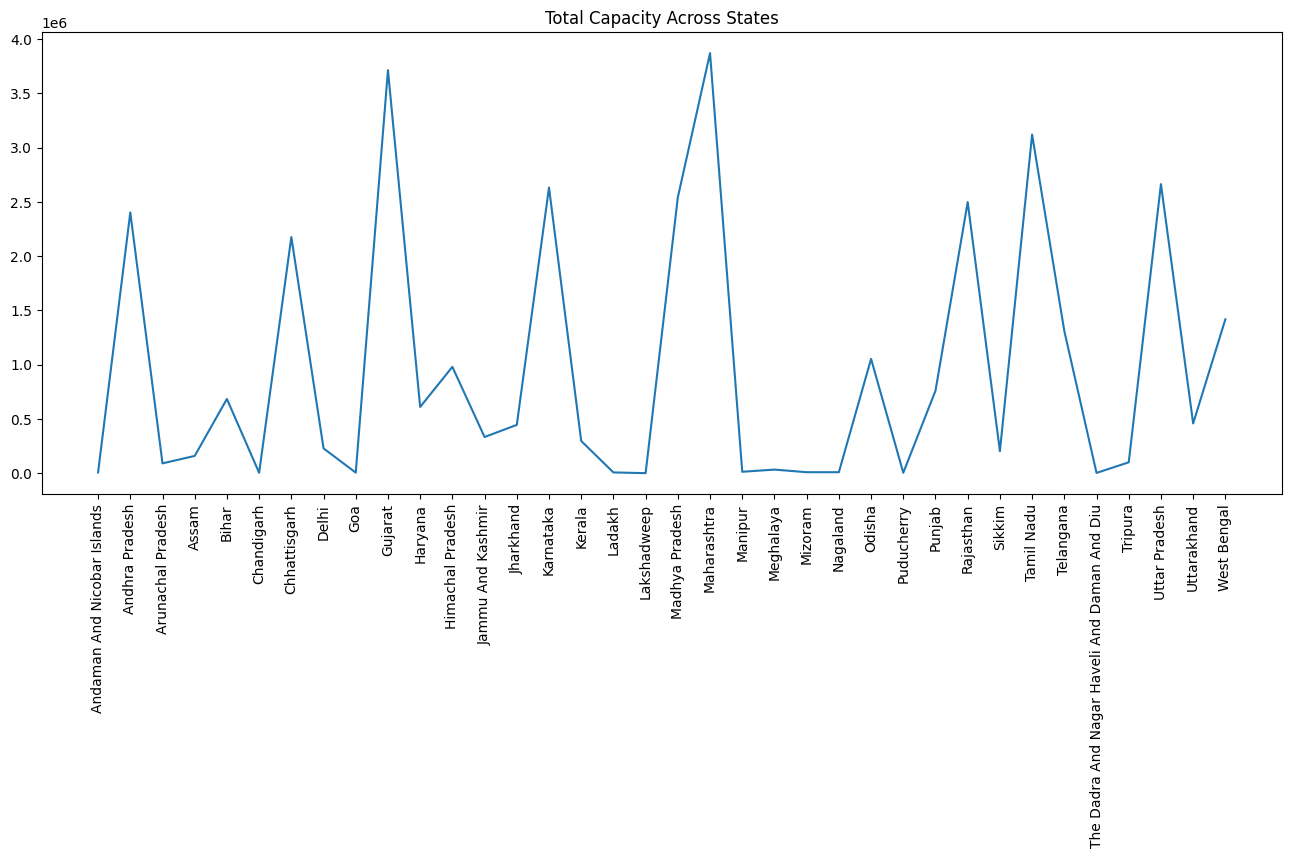

In [26]:
state_total = cp.groupby('State Name')['Total Cap'].sum()

plt.figure(figsize=(16,6))

plt.plot(state_total.index, state_total.values)

plt.xticks(rotation = 90)

plt.title('Total Capacity Across States')

plt.show()

This project analyzes the Installed Energy Capacity in India by State using Python libraries such as NumPy, Pandas, Matplotlib, Seaborn, and Plotly. The dataset contains information about different power generation capacities across Indian states, including coal, gas, hydro, nuclear, diesel, lignite, and renewable energy sources.

The analysis indicates that India still relies heavily on fossil fuels, especially coal, for electricity generation. However, renewable and clean energy capacities are steadily increasing across many states. The study highlights the growing importance of sustainable energy and the uneven distribution of energy infrastructure among Indian states.